# Austin Animal Shelter Analytics

An analytics warehouse built with **dbt + DuckDB** over the city of Austin's
open-data portal, answering operational questions from 347K raw intake/outcome
events (2013–2025).

**Layered architecture** (run by `dbt build`, all tested):

```
raw (portal CSVs, untouched)
  └─ staging  stg_intakes, stg_outcomes        typed, renamed, cleaned
      └─ intermediate  int_animal_stays      intakes paired with outcomes
          └─ marts  dim_animal, dim_date, fct_intakes, fct_outcomes,
                    mart_stay_analytics        analysis-ready star schema
```

Every chart below is a warehouse query. Findings are summarized at the end.

In [1]:
%matplotlib inline

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

con = duckdb.connect("warehouse/animal_shelter.duckdb", read_only=True)


def q(sql: str) -> pd.DataFrame:
    return con.execute(sql).df()


print("connected")

connected


## The raw layer is faithfully messy

In [2]:
counts = q("""
    select 'intakes' as table_name, count(*) as rows from raw.intakes
    union all
    select 'outcomes', count(*) from raw.outcomes
""")
display(counts)

# The two files even disagree on timestamp format:
q("""
    select * from (select 'intake' as stream, "DateTime" as raw_datetime from raw.intakes limit 2) a
    union all
    select * from (select 'outcome' as stream, "DateTime" as raw_datetime from raw.outcomes limit 2) b
""")

,table_name,rows
0,intakes,173812
1,outcomes,173775


,stream,raw_datetime
0,intake,10/01/2013 07:51:00 AM
1,intake,10/01/2013 08:33:00 AM
2,outcome,2013-12-02T00:00:00-05:00
3,outcome,2014-02-22T00:00:00-05:00


Raw quirks we found and handle in staging: two different datetime formats, age
strings like `"8 weeks"` / `"-1 years"`, location typos (`"Norht Ec"`), duplicate
outcome rows, and animals whose recorded outcome **precedes** their intake. The
staging layer types and cleans; the data tests guarantee it.

## Staging: ages parsed, timestamps unified

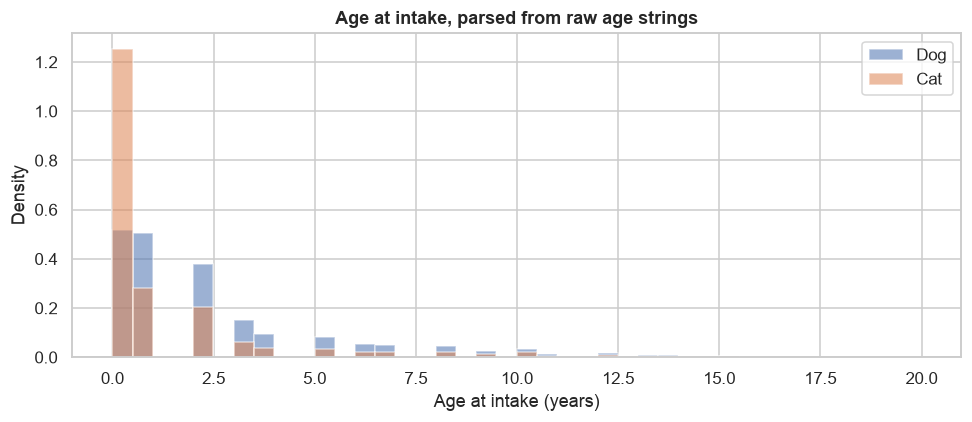

In [3]:
age_check = q("""
    select animal_type, age_upon_intake_years
    from stg_intakes
    where age_upon_intake_years between 0 and 20
""")
fig, ax = plt.subplots(figsize=(9, 4))
for species, color in [("Dog", "#4C72B0"), ("Cat", "#DD8452")]:
    subset = age_check.loc[age_check["animal_type"] == species, "age_upon_intake_years"]
    ax.hist(subset, bins=40, alpha=0.55, density=True, color=color, label=species)
ax.set_xlabel("Age at intake (years)")
ax.set_ylabel("Density")
ax.set_title("Age at intake, parsed from raw age strings")
ax.legend()
plt.tight_layout()
plt.show()

## Stays: pairing intakes with outcomes

The core transformation: each intake is paired with the animal's next outcome. Rows that can't logically exist (outcome before intake) are flagged, not hidden.

In [4]:
statuses = q("""
    select stay_status, count(*) as stays,
           round(100.0 * count(*) / sum(count(*)) over (), 2) as pct
    from int_animal_stays group by 1 order by stays desc
""")
display(statuses)

,stay_status,stays,pct
0,completed,172182,99.56
1,data_quality_issue,766,0.44


## Analysis 1 — Monthly flow: is the shelter getting more animals than it releases?

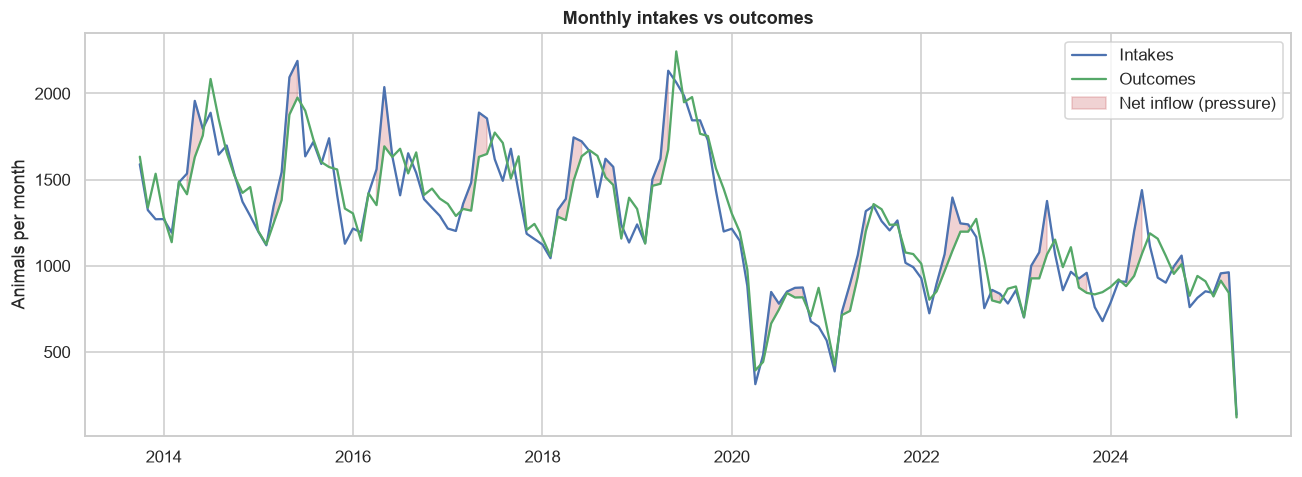

In [5]:
flow = q("""
    select * from (
        select intake_month as month, count(*) as intakes
        from stg_intakes group by 1
    ) i
    full outer join (
        select outcome_month as month, count(*) as outcomes
        from stg_outcomes group by 1
    ) o using (month)
    order by month
""")
flow["net_inflow"] = flow["intakes"] - flow["outcomes"]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(flow["month"], flow["intakes"], color="#4C72B0", lw=1.5, label="Intakes")
ax.plot(flow["month"], flow["outcomes"], color="#55A868", lw=1.5, label="Outcomes")
ax.fill_between(flow["month"], flow["intakes"], flow["outcomes"],
                where=flow["net_inflow"] > 0, color="#C44E52", alpha=0.25,
                label="Net inflow (pressure)")
ax.set_title("Monthly intakes vs outcomes")
ax.set_ylabel("Animals per month")
ax.legend()
plt.tight_layout()
plt.show()

## Analysis 2 — Outcome mix by species

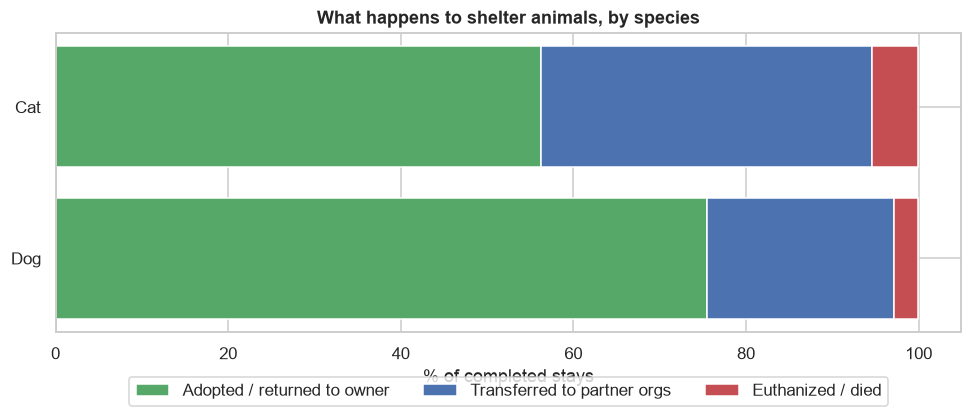

,animal_type,positive_pct,transfer_pct,negative_pct
0,Dog,75.4,21.7,2.8
1,Cat,56.2,38.4,5.3


In [6]:
mix = q("""
    select * from (
        select animal_type,
               100.0 * count(*) filter (where outcome_category = 'positive') / count(*) as positive_pct,
               100.0 * count(*) filter (where outcome_category = 'transfer') / count(*) as transfer_pct,
               100.0 * count(*) filter (where outcome_category = 'negative') / count(*) as negative_pct
        from mart_stay_analytics
        where animal_type in ('Dog', 'Cat')
        group by 1
    ) order by animal_type desc
""")
fig, ax = plt.subplots(figsize=(9, 4))
bottom = pd.Series(0.0, index=mix.index)
for col, color, label in [("positive_pct", "#55A868", "Adopted / returned to owner"),
                          ("transfer_pct", "#4C72B0", "Transferred to partner orgs"),
                          ("negative_pct", "#C44E52", "Euthanized / died")]:
    ax.barh(mix["animal_type"], mix[col], left=bottom, color=color, label=label)
    bottom += mix[col]
ax.set_xlabel("% of completed stays")
ax.set_title("What happens to shelter animals, by species")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.show()
display(mix.round(1))

## Analysis 3 — Length of stay

,animal_type,median_days,mean_days,pct_over_30d
0,Cat,7.0,23.3,25.5
1,Dog,6.0,21.0,15.8


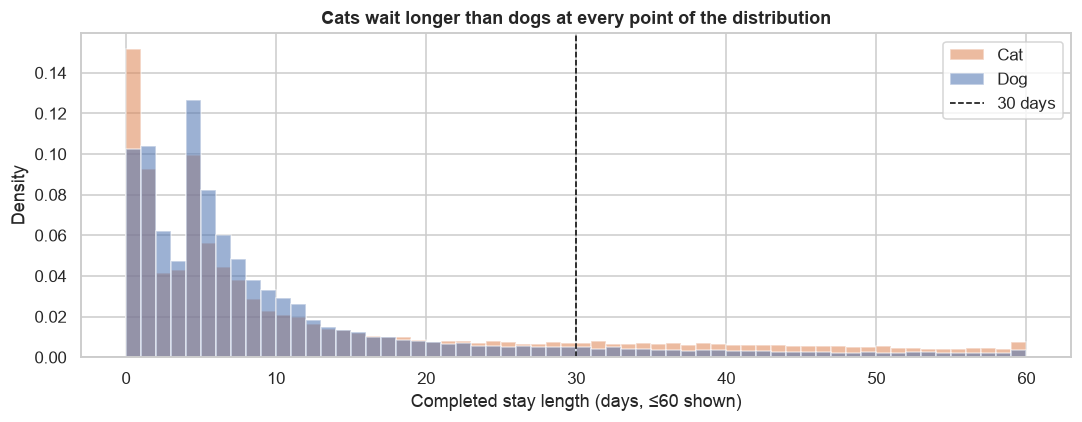

In [7]:
los = q("""
    select animal_type, stay_days
    from mart_stay_analytics
    where animal_type in ('Dog', 'Cat') and stay_days <= 60
""")
summary = q("""
    select animal_type, round(median(stay_days), 1) as median_days,
           round(avg(stay_days), 1) as mean_days,
           round(100.0 * count(*) filter (where stay_days > 30) / count(*), 1) as pct_over_30d
    from mart_stay_analytics where animal_type in ('Dog', 'Cat')
    group by 1 order by 2 desc
""")
display(summary)

fig, ax = plt.subplots(figsize=(10, 4))
for species, color in [("Cat", "#DD8452"), ("Dog", "#4C72B0")]:
    subset = los.loc[los["animal_type"] == species, "stay_days"]
    ax.hist(subset, bins=60, alpha=0.55, density=True, color=color, label=species)
ax.axvline(30, color="black", ls="--", lw=1, label="30 days")
ax.set_xlabel("Completed stay length (days, ≤60 shown)")
ax.set_ylabel("Density")
ax.set_title("Cats wait longer than dogs at every point of the distribution")
ax.legend()
plt.tight_layout()
plt.show()

## Analysis 4 — Adoption rate by age band

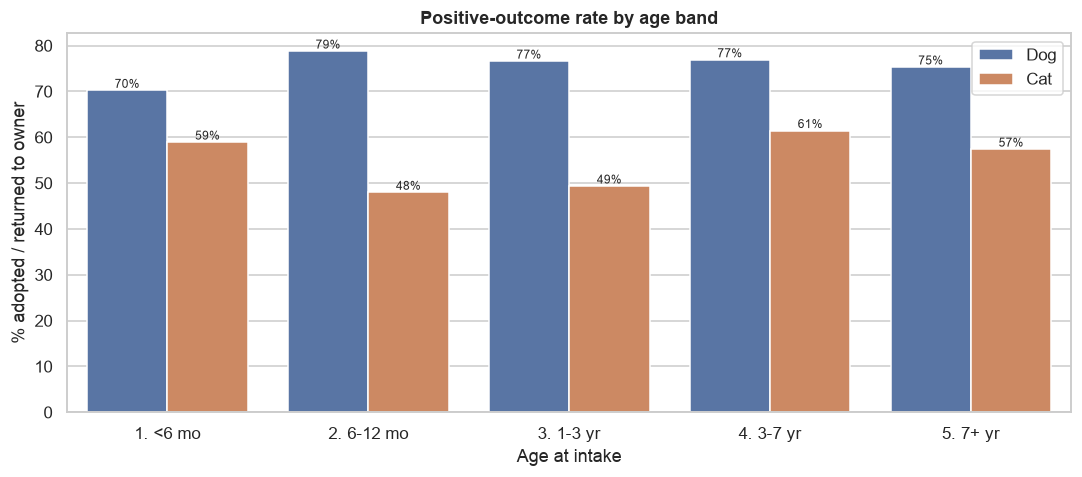

,age_band,animal_type,positive_pct,stays
0,1. <6 mo,Dog,70.2,24202
1,2. 6-12 mo,Dog,78.8,23761
2,3. 1-3 yr,Dog,76.6,24885
3,4. 3-7 yr,Dog,76.9,13227
4,5. 7+ yr,Dog,75.3,7737
5,1. <6 mo,Cat,58.9,42946
6,2. 6-12 mo,Cat,48.0,9641
7,3. 1-3 yr,Cat,49.3,9015
8,4. 3-7 yr,Cat,61.4,3870
9,5. 7+ yr,Cat,57.4,3119


In [8]:
age = q("""
    select * from (
        select
            case
                when age_upon_intake_years < 0.5 then '1. <6 mo'
                when age_upon_intake_years < 1 then '2. 6-12 mo'
                when age_upon_intake_years < 3 then '3. 1-3 yr'
                when age_upon_intake_years < 7 then '4. 3-7 yr'
                else '5. 7+ yr'
            end as age_band,
            animal_type,
            100.0 * count(*) filter (where outcome_category = 'positive') / count(*) as positive_pct,
            count(*) as stays
        from mart_stay_analytics
        where animal_type in ('Dog', 'Cat') and age_upon_intake_years is not null
        group by 1, 2
    ) order by animal_type desc, age_band
""")
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=age, x="age_band", y="positive_pct", hue="animal_type", ax=ax,
            palette=["#4C72B0", "#DD8452"])
ax.set_xlabel("Age at intake")
ax.set_ylabel("% adopted / returned to owner")
ax.set_title("Positive-outcome rate by age band")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", fontsize=8)
ax.legend(title="")
plt.tight_layout()
plt.show()
display(age.round(1))

## Analysis 5 — Top breeds by volume (dogs, ≥500 stays)

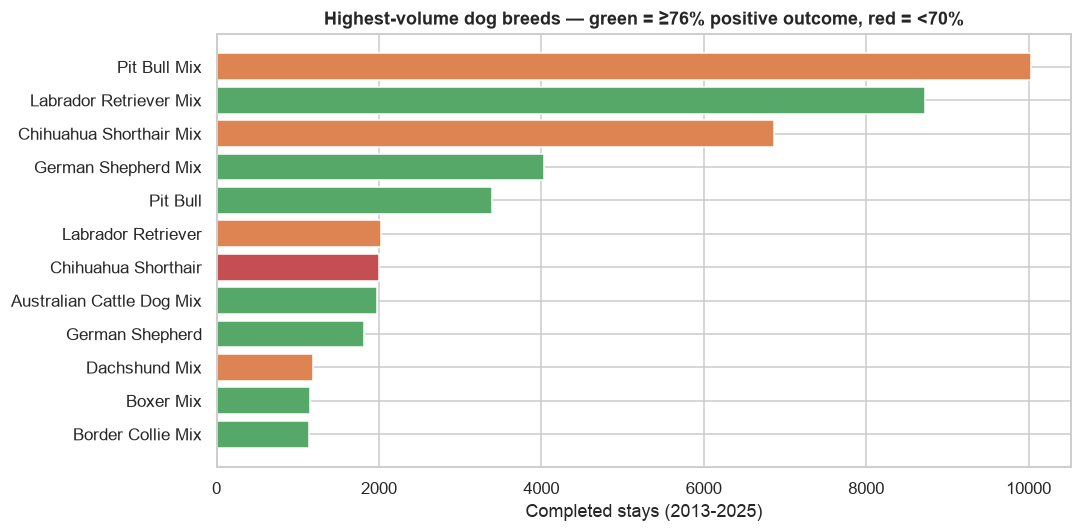

,breed,stays,median_stay_days,positive_pct
0,Pit Bull Mix,10026,9.0,75.1
1,Labrador Retriever Mix,8728,6.0,77.1
2,Chihuahua Shorthair Mix,6863,5.0,71.7
3,German Shepherd Mix,4028,7.0,79.7
4,Pit Bull,3397,12.0,77.5
5,Labrador Retriever,2021,7.0,72.3
6,Chihuahua Shorthair,2003,5.0,68.7
7,Australian Cattle Dog Mix,1975,7.0,77.6
8,German Shepherd,1820,7.0,83.0
9,Dachshund Mix,1182,5.0,72.8


In [9]:
breeds = q("""
    select * from (
        select breed, count(*) as stays,
               round(median(stay_days), 1) as median_stay_days,
               100.0 * count(*) filter (where outcome_category = 'positive') / count(*) as positive_pct
        from mart_stay_analytics
        where animal_type = 'Dog'
        group by 1 having count(*) >= 500
    ) order by stays desc limit 12
""")
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#C44E52" if v < 70 else ("#DD8452" if v < 76 else "#55A868")
              for v in breeds["positive_pct"]]
ax.barh(breeds["breed"][::-1], breeds["stays"][::-1], color=bar_colors[::-1])
ax.set_xlabel("Completed stays (2013-2025)")
ax.set_title("Highest-volume dog breeds — green = ≥76% positive outcome, red = <70%")
plt.tight_layout()
plt.show()
display(breeds.round(1))

## Findings

1. **The system is balanced, not structurally overloaded.** Monthly outcomes track
   intakes closely; sustained pressure appears only in spring/summer "kitten season"
   spikes, not as a long-term deficit.
2. **Species inequality is the biggest operational fact.** 75% of dog stays end in a
   positive outcome (adoption or owner reunion) vs 56% of cats; cats are also
   transferred out at nearly double the rate and wait longer (median 7 vs 6 days,
   25.5% vs 15.8% still in care past 30 days).
3. **The age cliff is real but species-specific.** Dogs adopt at 70-79% across every
   age band. Cats show a U-shape: kittens (<6 mo, 59%) do fine, but the 6-12 month
   band collapses to 48% — adolescent cats are the hardest population to place.
4. **Volume ≠ doom.** Pit Bull Mix is the #1 breed by volume (10,026 stays) yet
   achieves a 75% positive-outcome rate, beating several "popular" breeds.
5. **The portal data needs the guardrails we built.** Duplicate outcomes, two
   datetime formats, impossible age strings, and 46 animals with no outcome at all —
   all caught by the test suite (30 dbt tests + 5 pipeline tests).

## What is tested

- **staging**: not-null keys, parsed timestamps, valid species/values
- **intermediate/marts**: grain (one row per stay), reconciliation
  (staged rows = fact rows), no negative stays, exhaustive outcome categories
- **monitoring**: unknown-outcome rate kept under 1% (today: 0.03%)
- **pipeline tests (pytest)**: duplicate outcomes never multiply stays;
  outcome-before-intake is flagged as a data-quality issue, never silently paired